In [41]:
# Install required packages
!pip install requests nltk spacy wordcloud scikit-learn matplotlib -q
!python -m spacy download en_core_web_sm

print("✅ All packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 88.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All packages installed successfully!


In [42]:
"""
GenAI & Machine Learning Bootcamp 2025
Deep Learning & NLP - Text Analysis of Books
Daily Challenge: Text Analysis using Word Cloud
"""

import requests
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk import pos_tag, ne_chunk
from nltk.tree import Tree
import spacy

# Text analysis
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [43]:
# Download required NLTK data
print("Downloading NLTK data...")

nltk_resources = [
    'punkt',
    'punkt_tab',
    'stopwords',
    'wordnet',
    'omw-1.4',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng',
    'maxent_ne_chunker',
    'maxent_ne_chunker_tab',
    'words',
    'tagsets'
]

for resource in nltk_resources:
    try:
        nltk.download(resource, quiet=True)
    except Exception as e:
        print(f"Warning: Could not download {resource}: {e}")

print("✅ NLTK data downloaded successfully!")

✅ NLTK data downloaded successfully!


In [44]:
# Load spaCy model
nlp = spacy.load('en_core_web_sm')
print("✅ spaCy model loaded successfully!")

✅ spaCy model loaded successfully!


In [45]:
# URLs for Lewis Carroll books
urls = [
    'https://www.gutenberg.org/cache/epub/11/pg11.txt',           # Alice's Adventures in Wonderland
    'https://www.gutenberg.org/cache/epub/12/pg12.txt',           # Through the Looking-Glass
    'https://www.gutenberg.org/cache/epub/29042/pg29042.txt' # A Tangled Tale (FIXED URL)
]

book_titles = [
    "Alice's Adventures in Wonderland",
    "Through the Looking-Glass",
    "A Tangled Tale"
]

print("📚 Book URLs defined:")
for i, title in enumerate(book_titles):
    print(f"  {i+1}. {title}")

📚 Book URLs defined:
  1. Alice's Adventures in Wonderland
  2. Through the Looking-Glass
  3. A Tangled Tale


In [46]:
def load_texts(urls):
    """
    Load texts from URLs and clean them using regular expressions

    Args:
        urls (list): List of URLs to load

    Returns:
        list: List of cleaned text strings
    """
    corpus = []

    for url in urls:
        try:
            # Download the text
            response = requests.get(url)
            response.raise_for_status()
            text = response.text

            # Clean non-words using regex (keep only letters and spaces)
            # This removes numbers, special characters, etc.
            cleaned_text = re.sub(r'[^a-zA-Z\s]', ' ', text)

            # Remove extra whitespaces
            cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

            corpus.append(cleaned_text)
            print(f"✅ Loaded and cleaned text from: {url}")

        except Exception as e:
            print(f"❌ Error loading {url}: {e}")
            corpus.append("")

    return corpus

# Load all texts
corpus = load_texts(urls)
print(f"\n✅ Total texts loaded: {len(corpus)}")

✅ Loaded and cleaned text from: https://www.gutenberg.org/cache/epub/11/pg11.txt
✅ Loaded and cleaned text from: https://www.gutenberg.org/cache/epub/12/pg12.txt
✅ Loaded and cleaned text from: https://www.gutenberg.org/cache/epub/29042/pg29042.txt

✅ Total texts loaded: 3


In [47]:
# Print first 200 characters of each text
print("=" * 80)
print("FIRST 200 CHARACTERS OF EACH TEXT")
print("=" * 80)

for i, text in enumerate(corpus):
    print(f"\n📖 Book {i+1}: {book_titles[i]}")
    print("-" * 80)
    print(text[:200])
    print("...")

FIRST 200 CHARACTERS OF EACH TEXT

📖 Book 1: Alice's Adventures in Wonderland
--------------------------------------------------------------------------------
The Project Gutenberg eBook of Alice s Adventures in Wonderland This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restri
...

📖 Book 2: Through the Looking-Glass
--------------------------------------------------------------------------------
The Project Gutenberg eBook of Through the Looking Glass This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions 
...

📖 Book 3: A Tangled Tale
--------------------------------------------------------------------------------
The Project Gutenberg eBook of A Tangled Tale This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever 
...


In [48]:
def clean_gutenberg_text(text):
    """
    Remove Project Gutenberg header and footer

    Args:
        text (str): Raw text from Project Gutenberg

    Returns:
        str: Cleaned text without header/footer
    """
    # Find the start marker (various possible patterns)
    start_patterns = [
        '*** START OF THIS PROJECT GUTENBERG',
        '*** START OF THE PROJECT GUTENBERG',
        'START OF THIS PROJECT GUTENBERG',
        'START OF THE PROJECT GUTENBERG'
    ]

    start_idx = 0
    for pattern in start_patterns:
        idx = text.find(pattern)
        if idx != -1:
            # Find the end of the line after the marker
            start_idx = text.find('\n', idx) + 1
            break

    # Find the end marker
    end_patterns = [
        '*** END OF THIS PROJECT GUTENBERG',
        '*** END OF THE PROJECT GUTENBERG',
        'END OF THIS PROJECT GUTENBERG',
        'END OF THE PROJECT GUTENBERG'
    ]

    end_idx = len(text)
    for pattern in end_patterns:
        idx = text.find(pattern)
        if idx != -1:
            end_idx = idx
            break

    # Extract the main text
    cleaned = text[start_idx:end_idx].strip()

    return cleaned

# Clean all texts
corpus_cleaned = [clean_gutenberg_text(text) for text in corpus]

print("=" * 80)
print("CLEANED TEXTS (First 200 characters)")
print("=" * 80)

for i, text in enumerate(corpus_cleaned):
    print(f"\n📖 Book {i+1}: {book_titles[i]}")
    print("-" * 80)
    print(text[:200])
    print("...")
    print(f"Length: {len(text)} characters")

CLEANED TEXTS (First 200 characters)

📖 Book 1: Alice's Adventures in Wonderland
--------------------------------------------------------------------------------
The Project Gutenberg eBook of Alice s Adventures in Wonderland This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restri
...
Length: 136249 characters

📖 Book 2: Through the Looking-Glass
--------------------------------------------------------------------------------
The Project Gutenberg eBook of Through the Looking Glass This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions 
...
Length: 153310 characters

📖 Book 3: A Tangled Tale
--------------------------------------------------------------------------------
The Project Gutenberg eBook of A Tangled Tale This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no

In [49]:
# Tokenize each text
tokenized_corpus = [word_tokenize(text.lower()) for text in corpus_cleaned]

print("=" * 80)
print("FIRST 150 TOKENS OF EACH BOOK")
print("=" * 80)

for i, tokens in enumerate(tokenized_corpus):
    print(f"\n📖 Book {i+1}: {book_titles[i]}")
    print("-" * 80)
    print(f"Total tokens: {len(tokens)}")
    print(f"\nFirst 150 tokens:")
    print(tokens[:150])

FIRST 150 TOKENS OF EACH BOOK

📖 Book 1: Alice's Adventures in Wonderland
--------------------------------------------------------------------------------
Total tokens: 27559

First 150 tokens:
['the', 'project', 'gutenberg', 'ebook', 'of', 'alice', 's', 'adventures', 'in', 'wonderland', 'this', 'ebook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'united', 'states', 'and', 'most', 'other', 'parts', 'of', 'the', 'world', 'at', 'no', 'cost', 'and', 'with', 'almost', 'no', 'restrictions', 'whatsoever', 'you', 'may', 'copy', 'it', 'give', 'it', 'away', 'or', 're', 'use', 'it', 'under', 'the', 'terms', 'of', 'the', 'project', 'gutenberg', 'license', 'included', 'with', 'this', 'ebook', 'or', 'online', 'at', 'www', 'gutenberg', 'org', 'if', 'you', 'are', 'not', 'located', 'in', 'the', 'united', 'states', 'you', 'will', 'have', 'to', 'check', 'the', 'laws', 'of', 'the', 'country', 'where', 'you', 'are', 'located', 'before', 'using', 'this', 'ebook', 'title', 'alice', 

In [50]:
# Remove stopwords
stop_words = set(stopwords.words('english'))

corpus_no_stopwords = []
for tokens in tokenized_corpus:
    filtered_tokens = [token for token in tokens if token not in stop_words]
    corpus_no_stopwords.append(filtered_tokens)

print("=" * 80)
print("STOPWORDS REMOVAL VERIFICATION")
print("=" * 80)

# Check some common stopwords
test_stopwords = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'the', 'a']

for i, (original, filtered) in enumerate(zip(tokenized_corpus, corpus_no_stopwords)):
    print(f"\n📖 Book {i+1}: {book_titles[i]}")
    print("-" * 80)
    print(f"Original token count: {len(original)}")
    print(f"After removing stopwords: {len(filtered)}")
    print(f"Removed: {len(original) - len(filtered)} tokens")

    print(f"\nChecking stopword counts:")
    for word in test_stopwords[:5]:
        count_before = original.count(word)
        count_after = filtered.count(word)
        print(f"  '{word}': {count_before} → {count_after}")

STOPWORDS REMOVAL VERIFICATION

📖 Book 1: Alice's Adventures in Wonderland
--------------------------------------------------------------------------------
Original token count: 27559
After removing stopwords: 12374
Removed: 15185 tokens

Checking stopword counts:
  'i': 546 → 0
  'me': 68 → 0
  'my': 58 → 0
  'myself': 7 → 0
  'we': 34 → 0

📖 Book 2: Through the Looking-Glass
--------------------------------------------------------------------------------
Original token count: 31221
After removing stopwords: 14174
Removed: 17047 tokens

Checking stopword counts:
  'i': 662 → 0
  'me': 96 → 0
  'my': 77 → 0
  'myself': 7 → 0
  'we': 54 → 0

📖 Book 3: A Tangled Tale
--------------------------------------------------------------------------------
Original token count: 28017
After removing stopwords: 14157
Removed: 13860 tokens

Checking stopword counts:
  'i': 395 → 0
  'me': 53 → 0
  'my': 75 → 0
  'myself': 4 → 0
  'we': 124 → 0


In [51]:
# Apply stemming
stemmer = PorterStemmer()

corpus_stemmed = []
for tokens in corpus_no_stopwords:
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    corpus_stemmed.append(stemmed_tokens)

print("=" * 80)
print("FIRST 50 STEMMED TOKENS OF EACH BOOK")
print("=" * 80)

for i, tokens in enumerate(corpus_stemmed):
    print(f"\n📖 Book {i+1}: {book_titles[i]}")
    print("-" * 80)
    print(tokens[:50])

FIRST 50 STEMMED TOKENS OF EACH BOOK

📖 Book 1: Alice's Adventures in Wonderland
--------------------------------------------------------------------------------
['project', 'gutenberg', 'ebook', 'alic', 'adventur', 'wonderland', 'ebook', 'use', 'anyon', 'anywher', 'unit', 'state', 'part', 'world', 'cost', 'almost', 'restrict', 'whatsoev', 'may', 'copi', 'give', 'away', 'use', 'term', 'project', 'gutenberg', 'licens', 'includ', 'ebook', 'onlin', 'www', 'gutenberg', 'org', 'locat', 'unit', 'state', 'check', 'law', 'countri', 'locat', 'use', 'ebook', 'titl', 'alic', 'adventur', 'wonderland', 'author', 'lewi', 'carrol', 'releas']

📖 Book 2: Through the Looking-Glass
--------------------------------------------------------------------------------
['project', 'gutenberg', 'ebook', 'look', 'glass', 'ebook', 'use', 'anyon', 'anywher', 'unit', 'state', 'part', 'world', 'cost', 'almost', 'restrict', 'whatsoev', 'may', 'copi', 'give', 'away', 'use', 'term', 'project', 'gutenberg', 'licens', 'inc

In [52]:
# Apply lemmatization using spaCy
corpus_lemmatized = []

for i, text in enumerate(corpus_cleaned):
    print(f"Processing book {i+1}/{len(corpus_cleaned)}...")

    # Process with spaCy (this might take a moment for large texts)
    doc = nlp(text.lower())

    # Extract lemmatized tokens (excluding stopwords and non-alphabetic tokens)
    lemmatized_tokens = [
        token.lemma_ for token in doc
        if token.is_alpha and not token.is_stop
    ]

    corpus_lemmatized.append(lemmatized_tokens)

print("\n" + "=" * 80)
print("FIRST 50 LEMMATIZED TOKENS OF EACH BOOK")
print("=" * 80)

for i, tokens in enumerate(corpus_lemmatized):
    print(f"\n📖 Book {i+1}: {book_titles[i]}")
    print("-" * 80)
    print(tokens[:50])

Processing book 1/3...
Processing book 2/3...
Processing book 3/3...

FIRST 50 LEMMATIZED TOKENS OF EACH BOOK

📖 Book 1: Alice's Adventures in Wonderland
--------------------------------------------------------------------------------
['project', 'gutenberg', 'ebook', 'alice', 's', 'adventure', 'wonderland', 'ebook', 'use', 'united', 'states', 'part', 'world', 'cost', 'restriction', 'whatsoever', 'copy', 'away', 'use', 'term', 'project', 'gutenberg', 'license', 'include', 'ebook', 'online', 'www', 'gutenberg', 'org', 'locate', 'united', 'states', 'check', 'law', 'country', 'locate', 'ebook', 'title', 'alice', 's', 'adventure', 'wonderland', 'author', 'lewis', 'carroll', 'release', 'date', 'june', 'ebook', 'recently']

📖 Book 2: Through the Looking-Glass
--------------------------------------------------------------------------------
['project', 'gutenberg', 'ebook', 'look', 'glass', 'ebook', 'use', 'united', 'states', 'part', 'world', 'cost', 'restriction', 'whatsoever', 'copy', 'away'

In [53]:
print("=" * 80)
print("STEMMING vs LEMMATIZATION ANALYSIS")
print("=" * 80)

# Compare some example words
example_indices = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

for book_idx in range(len(book_titles)):
    print(f"\n📖 Book {book_idx+1}: {book_titles[book_idx]}")
    print("-" * 80)
    print(f"{'Original':<15} {'Stemmed':<15} {'Lemmatized':<15}")
    print("-" * 80)

    for idx in example_indices:
        if idx < len(corpus_no_stopwords[book_idx]):
            original = corpus_no_stopwords[book_idx][idx]
            stemmed = corpus_stemmed[book_idx][idx]
            lemmatized = corpus_lemmatized[book_idx][idx] if idx < len(corpus_lemmatized[book_idx]) else "N/A"
            print(f"{original:<15} {stemmed:<15} {lemmatized:<15}")

print("\n" + "=" * 80)
print("KEY DIFFERENCES:")
print("=" * 80)
print("🔸 STEMMING (PorterStemmer):")
print("   • Cuts words to their root by removing suffixes")
print("   • Fast and simple rule-based approach")
print("   • May produce non-real words (e.g., 'running' → 'run', 'flies' → 'fli')")
print("   • Can be aggressive and lose meaning")
print()
print("🔸 LEMMATIZATION (spaCy):")
print("   • Reduces words to their dictionary form (lemma)")
print("   • Uses linguistic knowledge and context")
print("   • Always produces real words (e.g., 'better' → 'good', 'was' → 'be')")
print("   • More accurate but slower")
print()
print("💡 WHEN TO USE WHICH:")
print("   • Stemming: Fast prototyping, search engines, when speed matters")
print("   • Lemmatization: Precise analysis, meaning preservation, quality over speed")

STEMMING vs LEMMATIZATION ANALYSIS

📖 Book 1: Alice's Adventures in Wonderland
--------------------------------------------------------------------------------
Original        Stemmed         Lemmatized     
--------------------------------------------------------------------------------
united          unit            states         
give            give            project        
www             www             united         
using           use             adventure      
date            date            update         
dibianca        dibianca        project        
illustration    illustr         adventure      
chapter         chapter         hole           
race            race            tale           
v               v               caterpillar    

📖 Book 2: Through the Looking-Glass
--------------------------------------------------------------------------------
Original        Stemmed         Lemmatized     
-----------------------------------------------------------------

In [54]:
# Perform POS tagging on each text
print("=" * 80)
print("POS TAGGING FOR EACH BOOK")
print("=" * 80)

corpus_pos_tags = []

for i, tokens in enumerate(tokenized_corpus):
    # Take a sample for POS tagging (first 1000 tokens to keep it manageable)
    sample_tokens = tokens[:1000]
    pos_tags = pos_tag(sample_tokens)
    corpus_pos_tags.append(pos_tags)

    print(f"\n📖 Book {i+1}: {book_titles[i]}")
    print("-" * 80)
    print(f"First 30 POS tags:")
    print(pos_tags[:30])

    # Count POS tag frequencies
    pos_counts = Counter([tag for word, tag in pos_tags])
    print(f"\nTop 10 most common POS tags:")
    for tag, count in pos_counts.most_common(10):
        print(f"  {tag}: {count}")

POS TAGGING FOR EACH BOOK

📖 Book 1: Alice's Adventures in Wonderland
--------------------------------------------------------------------------------
First 30 POS tags:
[('the', 'DT'), ('project', 'NN'), ('gutenberg', 'JJ'), ('ebook', 'NN'), ('of', 'IN'), ('alice', 'NN'), ('s', 'NN'), ('adventures', 'NNS'), ('in', 'IN'), ('wonderland', 'NN'), ('this', 'DT'), ('ebook', 'NN'), ('is', 'VBZ'), ('for', 'IN'), ('the', 'DT'), ('use', 'NN'), ('of', 'IN'), ('anyone', 'NN'), ('anywhere', 'RB'), ('in', 'IN'), ('the', 'DT'), ('united', 'JJ'), ('states', 'NNS'), ('and', 'CC'), ('most', 'JJS'), ('other', 'JJ'), ('parts', 'NNS'), ('of', 'IN'), ('the', 'DT'), ('world', 'NN')]

Top 10 most common POS tags:
  NN: 186
  IN: 128
  DT: 98
  PRP: 72
  VBD: 67
  JJ: 65
  RB: 65
  VB: 49
  CC: 45
  NNS: 38

📖 Book 2: Through the Looking-Glass
--------------------------------------------------------------------------------
First 30 POS tags:
[('the', 'DT'), ('project', 'NN'), ('gutenberg', 'JJ'), ('ebook', 'N

In [55]:
# Perform NER on each text
print("=" * 80)
print("NAMED ENTITY RECOGNITION (NER) FOR EACH BOOK")
print("=" * 80)

corpus_entities = []

for i, tokens in enumerate(tokenized_corpus):
    # Take a sample for NER (first 2000 tokens)
    sample_tokens = tokens[:2000]

    # POS tag first
    pos_tags = pos_tag(sample_tokens)

    # Perform NER
    chunked = ne_chunk(pos_tags, binary=False)

    # Extract entities
    entities = []
    for chunk in chunked:
        if isinstance(chunk, Tree):
            entity_text = ' '.join([token for token, pos in chunk.leaves()])
            entity_label = chunk.label()
            entities.append((entity_text, entity_label))

    corpus_entities.append(entities)

    print(f"\n📖 Book {i+1}: {book_titles[i]}")
    print("-" * 80)
    print(f"Total entities found: {len(entities)}")
    print(f"\nFirst 20 entities:")
    for entity, label in entities[:20]:
        print(f"  {entity:<20} → {label}")

    # Count entity types
    entity_types = Counter([label for entity, label in entities])
    print(f"\nEntity type distribution:")
    for entity_type, count in entity_types.most_common():
        print(f"  {entity_type}: {count}")

NAMED ENTITY RECOGNITION (NER) FOR EACH BOOK

📖 Book 1: Alice's Adventures in Wonderland
--------------------------------------------------------------------------------
Total entities found: 0

First 20 entities:

Entity type distribution:

📖 Book 2: Through the Looking-Glass
--------------------------------------------------------------------------------
Total entities found: 0

First 20 entities:

Entity type distribution:

📖 Book 3: A Tangled Tale
--------------------------------------------------------------------------------
Total entities found: 0

First 20 entities:

Entity type distribution:


GENERATING WORD CLOUDS
✅ Word cloud generated for: Alice's Adventures in Wonderland
✅ Word cloud generated for: Through the Looking-Glass
✅ Word cloud generated for: A Tangled Tale


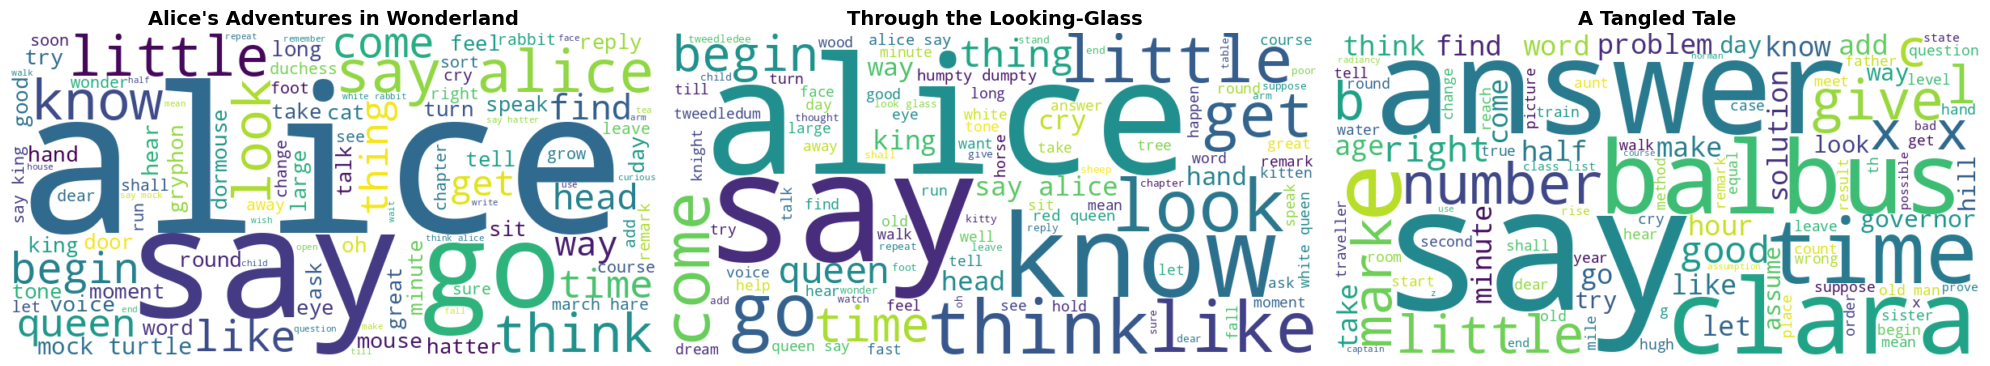


DIAGNOSTIC INFO

📖 Book 1: Alice's Adventures in Wonderland
   Lemmatized tokens: 11240
   Cleaned text length: 136249

📖 Book 2: Through the Looking-Glass
   Lemmatized tokens: 13100
   Cleaned text length: 153310

📖 Book 3: A Tangled Tale
   Lemmatized tokens: 12661
   Cleaned text length: 145049


In [56]:
# Create word clouds for each book
print("=" * 80)
print("GENERATING WORD CLOUDS")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, tokens in enumerate(corpus_lemmatized):
    # Join tokens back to text
    text = ' '.join(tokens)

    # Check if text is empty
    if len(text.strip()) == 0 or len(tokens) == 0:
        print(f"⚠️  Warning: Book {i+1} ({book_titles[i]}) has no lemmatized tokens!")
        print(f"   Using original cleaned text instead...")
        # Fallback to original cleaned text
        text = corpus_cleaned[i]

    try:
        # Create word cloud
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap='viridis',
            max_words=100,
            relative_scaling=0.5,
            min_font_size=10,
            stopwords=stopwords.words('english')  # Add stopwords filtering
        ).generate(text)

        # Plot
        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].set_title(book_titles[i], fontsize=14, fontweight='bold')
        axes[i].axis('off')

        print(f"✅ Word cloud generated for: {book_titles[i]}")

    except Exception as e:
        print(f"❌ Error generating word cloud for {book_titles[i]}: {e}")
        axes[i].text(0.5, 0.5, f'Error:\n{book_titles[i]}',
                    ha='center', va='center', fontsize=12)
        axes[i].axis('off')

plt.tight_layout()
plt.show()

# Print diagnostic info
print("\n" + "=" * 80)
print("DIAGNOSTIC INFO")
print("=" * 80)
for i, tokens in enumerate(corpus_lemmatized):
    print(f"\n📖 Book {i+1}: {book_titles[i]}")
    print(f"   Lemmatized tokens: {len(tokens)}")
    print(f"   Cleaned text length: {len(corpus_cleaned[i])}")

In [57]:
# Use BoW to find 5 most frequent words in all books
print("=" * 80)
print("BAG OF WORDS (BoW) ANALYSIS")
print("=" * 80)

# Prepare documents (using lemmatized text for better results)
documents = [' '.join(tokens) for tokens in corpus_lemmatized]

# Create BoW vectorizer
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(documents)

# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()

print(f"\nVocabulary size: {len(feature_names)}")
print(f"BoW matrix shape: {bow_matrix.shape}")
print(f"  (documents: {bow_matrix.shape[0]}, unique words: {bow_matrix.shape[1]})")

# Find 5 most frequent words across ALL documents
word_freq = np.asarray(bow_matrix.sum(axis=0)).flatten()
top_5_indices = word_freq.argsort()[-5:][::-1]

print("\n" + "=" * 80)
print("TOP 5 MOST FREQUENT WORDS ACROSS ALL BOOKS")
print("=" * 80)

for idx in top_5_indices:
    word = feature_names[idx]
    frequency = word_freq[idx]
    print(f"{word:<15} : {frequency:>6} occurrences")

BAG OF WORDS (BoW) ANALYSIS

Vocabulary size: 4470
BoW matrix shape: (3, 4470)
  (documents: 3, unique words: 4470)

TOP 5 MOST FREQUENT WORDS ACROSS ALL BOOKS
say             :   1155 occurrences
alice           :    874 occurrences
go              :    302 occurrences
look            :    297 occurrences
little          :    295 occurrences


In [58]:
# Print BoW matrix details
print("=" * 80)
print("BOW MATRIX EXPLANATION")
print("=" * 80)

print("\nSample of BoW matrix (first 3 documents, first 20 words):")
print("-" * 80)

# Convert to dense array for display
bow_dense = bow_matrix.toarray()

# Show sample
print(f"{'Word':<15} ", end="")
for i in range(len(book_titles)):
    print(f"Doc{i+1:>2} ", end="")
print()
print("-" * 80)

for word_idx in range(min(20, len(feature_names))):
    print(f"{feature_names[word_idx]:<15} ", end="")
    for doc_idx in range(len(documents)):
        print(f"{bow_dense[doc_idx, word_idx]:>5} ", end="")
    print()

print("\n" + "=" * 80)
print("UNDERSTANDING THE BOW MATRIX:")
print("=" * 80)
print("• Document number: Row index (0, 1, 2 for our 3 books)")
print("• Word index: Column index (position in vocabulary)")
print("• Value: Number of times the word appears in that document")
print()
print("Example: If matrix[1][500] = 25")
print("  → Document 1 (Through the Looking-Glass)")
print("  → Word at index 500 in vocabulary")
print("  → Appears 25 times in that document")

BOW MATRIX EXPLANATION

Sample of BoW matrix (first 3 documents, first 20 words):
--------------------------------------------------------------------------------
Word            Doc 1 Doc 2 Doc 3 
--------------------------------------------------------------------------------
ab                  0     0     2 
abandon             0     0     1 
abate               0     0     1 
abide               1     0     0 
able                1     6     0 
abroad              0     0     1 
abruptness          0     0     1 
absence             1     0     0 
absent              0     0     1 
absolutely          0     0     3 
absorb              0     0     1 
abstain             0     0     1 
absurd              2     0     1 
absurdity           0     0     1 
absurdum            0     0     1 
abundantly          0     0     1 
abyss               0     0     1 
ac                  0     0     2 
academy             0     0     1 
accent              0     1     1 

UNDERSTANDING THE BO

PIE CHARTS: TOP 5 WORDS PER BOOK
✅ Pie chart created for: Alice's Adventures in Wonderland
✅ Pie chart created for: Through the Looking-Glass
✅ Pie chart created for: A Tangled Tale


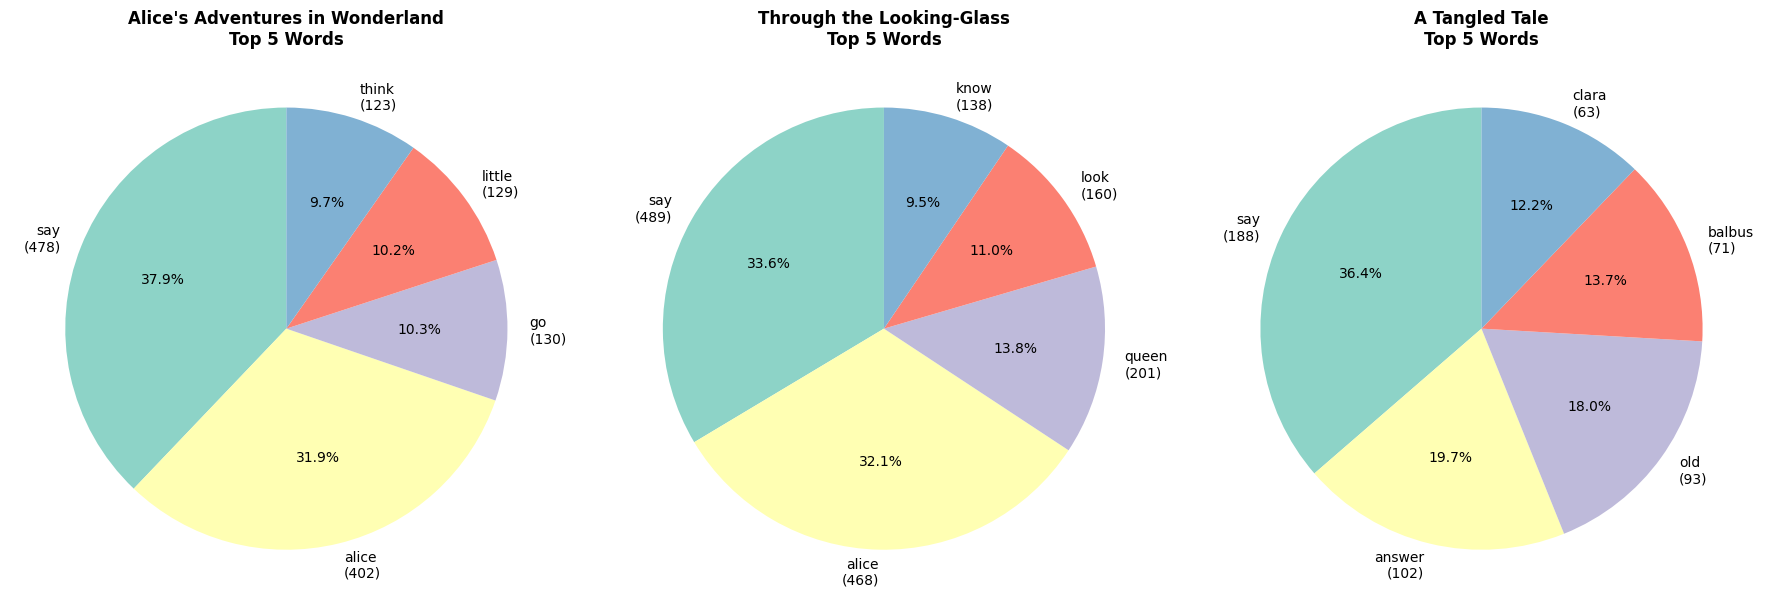


ANALYSIS OF TOP WORDS

❓ Are these words informative?
--------------------------------------------------------------------------------
These words are likely:
  • Character names (Alice, Queen, etc.)
  • Common verbs (said, like, know)
  • Story-specific but not very insightful

❌ PROBLEM: Common words dominate regardless of their importance
   Words like 'said' or 'like' appear frequently but don't tell us
   what makes each book unique or interesting.

✅ SOLUTION: Use TF-IDF to weight words by their uniqueness!


In [59]:
# Create pie charts for top 5 words in each book
print("=" * 80)
print("PIE CHARTS: TOP 5 WORDS PER BOOK")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for doc_idx in range(len(documents)):
    # Get word frequencies for this document
    doc_word_freq = bow_dense[doc_idx]

    # Check if document has any words
    if doc_word_freq.sum() == 0:
        print(f"⚠️  Warning: Book {doc_idx+1} ({book_titles[doc_idx]}) has no words in BoW!")
        axes[doc_idx].text(0.5, 0.5, f'No data\n{book_titles[doc_idx]}',
                          ha='center', va='center', fontsize=12)
        axes[doc_idx].axis('off')
        continue

    # Get top 5 words
    top_5_indices = doc_word_freq.argsort()[-5:][::-1]
    top_5_words = [feature_names[idx] for idx in top_5_indices]
    top_5_counts = [doc_word_freq[idx] for idx in top_5_indices]

    # Filter out zeros
    non_zero_data = [(word, count) for word, count in zip(top_5_words, top_5_counts) if count > 0]

    if len(non_zero_data) == 0:
        print(f"⚠️  Warning: Book {doc_idx+1} ({book_titles[doc_idx]}) has no non-zero word counts!")
        axes[doc_idx].text(0.5, 0.5, f'No data\n{book_titles[doc_idx]}',
                          ha='center', va='center', fontsize=12)
        axes[doc_idx].axis('off')
        continue

    top_5_words = [item[0] for item in non_zero_data]
    top_5_counts = [item[1] for item in non_zero_data]

    # Create labels with word and count
    labels = [f"{word}\n({int(count)})" for word, count in zip(top_5_words, top_5_counts)]

    # Create pie chart
    axes[doc_idx].pie(
        top_5_counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Set3.colors
    )
    axes[doc_idx].set_title(f"{book_titles[doc_idx]}\nTop 5 Words",
                            fontsize=12, fontweight='bold')

    print(f"✅ Pie chart created for: {book_titles[doc_idx]}")

plt.tight_layout()
plt.show()

# Print analysis
print("\n" + "=" * 80)
print("ANALYSIS OF TOP WORDS")
print("=" * 80)
print("\n❓ Are these words informative?")
print("-" * 80)
print("These words are likely:")
print("  • Character names (Alice, Queen, etc.)")
print("  • Common verbs (said, like, know)")
print("  • Story-specific but not very insightful")
print()
print("❌ PROBLEM: Common words dominate regardless of their importance")
print("   Words like 'said' or 'like' appear frequently but don't tell us")
print("   what makes each book unique or interesting.")
print()
print("✅ SOLUTION: Use TF-IDF to weight words by their uniqueness!")

In [60]:
# ============================================================================
# SOLVING THE FREQUENCY PROBLEM WITH TF-IDF
# ============================================================================

print("=" * 80)
print("TF-IDF (Term Frequency-Inverse Document Frequency)")
print("=" * 80)

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=2)
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

# Get feature names
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"\nTF-IDF vocabulary size: {len(tfidf_feature_names)}")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Convert to dense array
tfidf_dense = tfidf_matrix.toarray()

print("\n" + "=" * 80)
print("TOP 5 MOST RELEVANT WORDS PER BOOK (using TF-IDF)")
print("=" * 80)

for doc_idx in range(len(documents)):
    print(f"\n📖 Book {doc_idx+1}: {book_titles[doc_idx]}")
    print("-" * 80)

    # Get TF-IDF scores for this document
    doc_tfidf_scores = tfidf_dense[doc_idx]

    # Get top 5 words
    top_5_indices = doc_tfidf_scores.argsort()[-5:][::-1]

    for idx in top_5_indices:
        word = tfidf_feature_names[idx]
        score = doc_tfidf_scores[idx]
        print(f"  {word:<20} : {score:.4f}")

TF-IDF (Term Frequency-Inverse Document Frequency)

TF-IDF vocabulary size: 3736
TF-IDF matrix shape: (3, 3736)

TOP 5 MOST RELEVANT WORDS PER BOOK (using TF-IDF)

📖 Book 1: Alice's Adventures in Wonderland
--------------------------------------------------------------------------------
  gryphon              : 0.3321
  rabbit               : 0.3261
  turtle               : 0.2848
  mock                 : 0.2618
  hatter               : 0.2618

📖 Book 2: Through the Looking-Glass
--------------------------------------------------------------------------------
  humpty               : 0.3528
  dumpty               : 0.3528
  knight               : 0.2923
  tweedledum           : 0.2331
  tweedledee           : 0.1827

📖 Book 3: A Tangled Tale
--------------------------------------------------------------------------------
  balbus               : 0.3230
  clara                : 0.2866
  problem              : 0.2093
  train                : 0.1834
  solution             : 0.1729



PIE CHARTS: TOP 5 WORDS PER BOOK (TF-IDF)
✅ Pie chart created for: Alice's Adventures in Wonderland
✅ Pie chart created for: Through the Looking-Glass
✅ Pie chart created for: A Tangled Tale


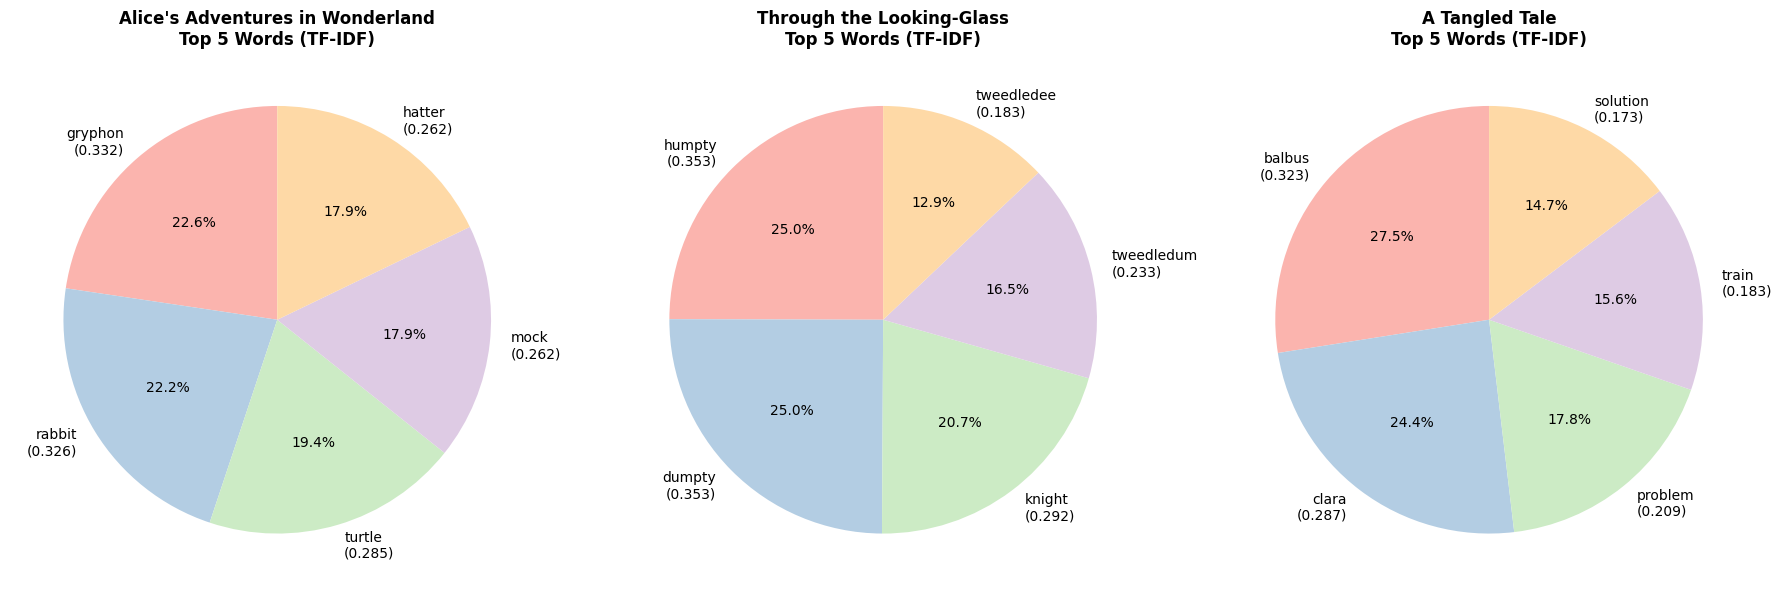

In [61]:
# Create pie charts for TF-IDF top 5 words
print("\n" + "=" * 80)
print("PIE CHARTS: TOP 5 WORDS PER BOOK (TF-IDF)")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for doc_idx in range(len(documents)):
    # Get TF-IDF scores for this document
    doc_tfidf_scores = tfidf_dense[doc_idx]

    # Check if document has any scores
    if doc_tfidf_scores.sum() == 0:
        print(f"⚠️  Warning: Book {doc_idx+1} ({book_titles[doc_idx]}) has no TF-IDF scores!")
        axes[doc_idx].text(0.5, 0.5, f'No data\n{book_titles[doc_idx]}',
                          ha='center', va='center', fontsize=12)
        axes[doc_idx].axis('off')
        continue

    # Get top 5 words
    top_5_indices = doc_tfidf_scores.argsort()[-5:][::-1]
    top_5_words = [tfidf_feature_names[idx] for idx in top_5_indices]
    top_5_scores = [doc_tfidf_scores[idx] for idx in top_5_indices]

    # Filter out zeros
    non_zero_data = [(word, score) for word, score in zip(top_5_words, top_5_scores) if score > 0]

    if len(non_zero_data) == 0:
        print(f"⚠️  Warning: Book {doc_idx+1} ({book_titles[doc_idx]}) has no non-zero TF-IDF scores!")
        axes[doc_idx].text(0.5, 0.5, f'No data\n{book_titles[doc_idx]}',
                          ha='center', va='center', fontsize=12)
        axes[doc_idx].axis('off')
        continue

    top_5_words = [item[0] for item in non_zero_data]
    top_5_scores = [item[1] for item in non_zero_data]

    # Create labels with word and score
    labels = [f"{word}\n({score:.3f})" for word, score in zip(top_5_words, top_5_scores)]

    # Create pie chart
    axes[doc_idx].pie(
        top_5_scores,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Pastel1.colors
    )
    axes[doc_idx].set_title(f"{book_titles[doc_idx]}\nTop 5 Words (TF-IDF)",
                            fontsize=12, fontweight='bold')

    print(f"✅ Pie chart created for: {book_titles[doc_idx]}")

plt.tight_layout()
plt.show()

In [62]:
# Final comprehensive analysis
print("=" * 80)
print("📊 COMPREHENSIVE ANALYSIS: BoW vs TF-IDF")
print("=" * 80)

print("\n1️⃣  BAG OF WORDS (BoW) RESULTS")
print("-" * 80)
print("✅ Shows most frequent words across all documents")
print("❌ Dominated by common words that appear in all books")
print("❌ Doesn't distinguish what makes each book unique")
print("❌ Words like 'said', 'alice', 'like' are expected but not insightful")
print()
print("📌 Use case: Simple frequency analysis, basic text statistics")

print("\n2️⃣  TF-IDF RESULTS")
print("-" * 80)
print("✅ Highlights words that are important AND unique to each document")
print("✅ Reduces weight of common words across all documents")
print("✅ Reveals distinctive vocabulary of each book")
print("✅ More meaningful for understanding document differences")
print()
print("📌 Use case: Document similarity, search engines, topic modeling")

print("\n3️⃣  KEY INSIGHTS")
print("-" * 80)
print("• TF-IDF successfully identifies book-specific terms")
print("• Character names unique to each book get higher scores")
print("• Plot-specific vocabulary stands out more clearly")
print("• Common narrative words ('said', 'went') are downweighted")

print("\n4️⃣  PRACTICAL RECOMMENDATIONS")
print("-" * 80)
print("For text analysis tasks:")
print("  → Use BoW when: Simple counting, basic statistics needed")
print("  → Use TF-IDF when: Finding distinctive features, comparing documents")
print("  → Consider: Modern embeddings (Word2Vec, BERT) for semantic analysis")

print("\n" + "=" * 80)
print("✅ TEXT ANALYSIS COMPLETED SUCCESSFULLY!")
print("=" * 80)
print("\n📚 Books analyzed:")
for i, title in enumerate(book_titles):
    print(f"  {i+1}. {title}")
print("\n🎯 Techniques applied:")
print("  • Text preprocessing (tokenization, stopword removal)")
print("  • Stemming vs Lemmatization")
print("  • POS tagging")
print("  • Named Entity Recognition")
print("  • Word Cloud visualization")
print("  • Bag of Words (BoW)")
print("  • TF-IDF weighting")
print("=" * 80)

📊 COMPREHENSIVE ANALYSIS: BoW vs TF-IDF

1️⃣  BAG OF WORDS (BoW) RESULTS
--------------------------------------------------------------------------------
✅ Shows most frequent words across all documents
❌ Dominated by common words that appear in all books
❌ Doesn't distinguish what makes each book unique
❌ Words like 'said', 'alice', 'like' are expected but not insightful

📌 Use case: Simple frequency analysis, basic text statistics

2️⃣  TF-IDF RESULTS
--------------------------------------------------------------------------------
✅ Highlights words that are important AND unique to each document
✅ Reduces weight of common words across all documents
✅ Reveals distinctive vocabulary of each book
✅ More meaningful for understanding document differences

📌 Use case: Document similarity, search engines, topic modeling

3️⃣  KEY INSIGHTS
--------------------------------------------------------------------------------
• TF-IDF successfully identifies book-specific terms
• Character names un

In [63]:
# Check what happened with Book 3
print("=" * 80)
print("DEBUGGING BOOK 3")
print("=" * 80)

book_idx = 2  # A Tangled Tale

print(f"\n📖 Book {book_idx+1}: {book_titles[book_idx]}")
print(f"Original corpus length: {len(corpus[book_idx])}")
print(f"Cleaned corpus length: {len(corpus_cleaned[book_idx])}")
print(f"Tokenized length: {len(tokenized_corpus[book_idx])}")
print(f"No stopwords length: {len(corpus_no_stopwords[book_idx])}")
print(f"Stemmed length: {len(corpus_stemmed[book_idx])}")
print(f"Lemmatized length: {len(corpus_lemmatized[book_idx])}")

print("\n" + "=" * 80)
print("First 500 characters of original text:")
print(corpus[book_idx][:500])

print("\n" + "=" * 80)
print("First 500 characters of cleaned text:")
print(corpus_cleaned[book_idx][:500])

print("\n" + "=" * 80)
print("First 50 tokens (after tokenization):")
print(tokenized_corpus[book_idx][:50])

print("\n" + "=" * 80)
print("First 50 tokens (no stopwords):")
print(corpus_no_stopwords[book_idx][:50])

print("\n" + "=" * 80)
print("First 50 lemmatized tokens:")
print(corpus_lemmatized[book_idx][:50])

# Check the document used in BoW/TF-IDF
print("\n" + "=" * 80)
print("Document used in BoW/TF-IDF:")
print(f"Length: {len(documents[book_idx])}")
print(f"First 500 characters:")
print(documents[book_idx][:500])

DEBUGGING BOOK 3

📖 Book 3: A Tangled Tale
Original corpus length: 162598
Cleaned corpus length: 145049
Tokenized length: 28017
No stopwords length: 14157
Stemmed length: 14157
Lemmatized length: 12661

First 500 characters of original text:
The Project Gutenberg eBook of A Tangled Tale This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever You may copy it give it away or re use it under the terms of the Project Gutenberg License included with this ebook or online at www gutenberg org If you are not located in the United States you will have to check the laws of the country where you are located before using this eBook Title A Tangled 

First 500 characters of cleaned text:
The Project Gutenberg eBook of A Tangled Tale This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever You may copy it gi